# Result Analysis

This notebook loads the append-only CSV outputs from `results/attack_results/` and `results/algorithm_results/` and summarizes attack reconstruction quality and model performance.

In [1]:
from analysis_utils import (
    load_attack_results,
    load_algorithm_results,
    attack_summary,
    algorithm_summary,
    plot_attack_metric,
    plot_attack_metric_by_round,
    plot_algorithm_crossentropy,
    plot_algorithm_accuracy,
    combine_csvs
)

combined_attack_results_path = combine_csvs(("./results/attack_results/dlg/raw_results.csv", "./results/attack_results/ig/raw_results.csv"), "./results/attack_results/raw_results.csv")
combined_algorithm_results_path = combine_csvs(("./results/algorithm_results/dlg/raw_results.csv", "./results/algorithm_results/ig/raw_results.csv"), "./results/algorithm_results/raw_results.csv")

attack_rows = load_attack_results(combined_attack_results_path)
algorithm_rows = load_algorithm_results(combined_algorithm_results_path)

attack_rows[:3] if isinstance(attack_rows, list) else attack_rows.head(), algorithm_rows[:3] if isinstance(algorithm_rows, list) else algorithm_rows.head()

([{'index': '0',
   'run': '0',
   'communication_round': '1',
   'client_id': '0',
   'sample_index': '0',
   'algorithm': 'FedAvg',
   'attack': 'DLG',
   'real input value': '[[[0.2078431397676468, 0.25882354378700256, 0.5372549295425415], [0.1921568661928177, 0.24705882370471954, 0.5215686559677124], [0.1921568661928177, 0.25882354378700256, 0.529411792755127], [0.1882352977991104, 0.26274511218070984, 0.529411792755127], [0.19607843458652496, 0.26274511218070984, 0.5333333611488342], [0.2078431397676468, 0.27450981736183167, 0.545098066329956], [0.21176470816135406, 0.2823529541492462, 0.5490196347236633], [0.21568627655506134, 0.29411765933036804, 0.5568627715110779], [0.2078431397676468, 0.2980392277240753, 0.5568627715110779], [0.20392157137393951, 0.29411765933036804, 0.5529412031173706], [0.20392157137393951, 0.29019609093666077, 0.5607843399047852], [0.20000000298023224, 0.2980392277240753, 0.5686274766921997], [0.19607843458652496, 0.3137255012989044, 0.5803921818733215], [

## Summary Tables

In [2]:
attack_summary(attack_rows)

[{'algorithm': 'FedAvg',
  'attack': 'DLG',
  'rows': 50,
  'mean_mse': 0.037787976926192644,
  'min_mse': 0.004130569752305746,
  'max_mse': 0.2209281474351883,
  'mean_psnr': 17.1124605178833,
  'min_psnr': 6.557488918304443,
  'max_psnr': 23.83989906311035,
  'mean_ssim': 0.5050662951171399,
  'min_ssim': 0.03746085986495018,
  'max_ssim': 0.8400267958641052,
  'label_recover': 1.0},
 {'algorithm': 'FedAvg',
  'attack': 'InvertingGradients',
  'rows': 50,
  'mean_mse': 0.0049732632422819735,
  'min_mse': 0.0011510676704347134,
  'max_mse': 0.013047334738075733,
  'mean_psnr': 23.505816612243652,
  'min_psnr': 18.84478187561035,
  'max_psnr': 29.38899040222168,
  'mean_ssim': 0.7908157229423523,
  'min_ssim': 0.4370023012161255,
  'max_ssim': 0.9402216076850891,
  'label_recover': 1.0},
 {'algorithm': 'FedPer(K_p=1)',
  'attack': 'DLG',
  'rows': 50,
  'mean_mse': 0.09189408010803163,
  'min_mse': 0.006880099419504404,
  'max_mse': 0.29295840859413147,
  'mean_psnr': 11.8632601737976

In [3]:
algorithm_summary(algorithm_rows)

[{'algorithm': 'FedAvg',
  'rows': 100,
  'mean_crossentropy': 2.308904938697815,
  'min_crossentropy': 2.2181568145751953,
  'max_crossentropy': 2.5341105461120605,
  'accuracy': 0.1},
 {'algorithm': 'FedPer(K_p=1)',
  'rows': 100,
  'mean_crossentropy': 0.04288608744740486,
  'min_crossentropy': 0.0401453822851181,
  'max_crossentropy': 0.04562903195619583,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(K_p=2)',
  'rows': 100,
  'mean_crossentropy': 0.033675872199237344,
  'min_crossentropy': 0.028511730954051018,
  'max_crossentropy': 0.039890315383672714,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(K_p=3)',
  'rows': 100,
  'mean_crossentropy': 0.03339805245399475,
  'min_crossentropy': 0.02814091555774212,
  'max_crossentropy': 0.039773013442754745,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(K_p=4)',
  'rows': 100,
  'mean_crossentropy': 0.03336236353963613,
  'min_crossentropy': 0.02810150757431984,
  'max_crossentropy': 0.03975697606801987,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(

## Attack Comparisons

<Axes: title={'center': 'Mean input mse by algorithm and attack'}, xlabel='Algorithm', ylabel='input mse'>

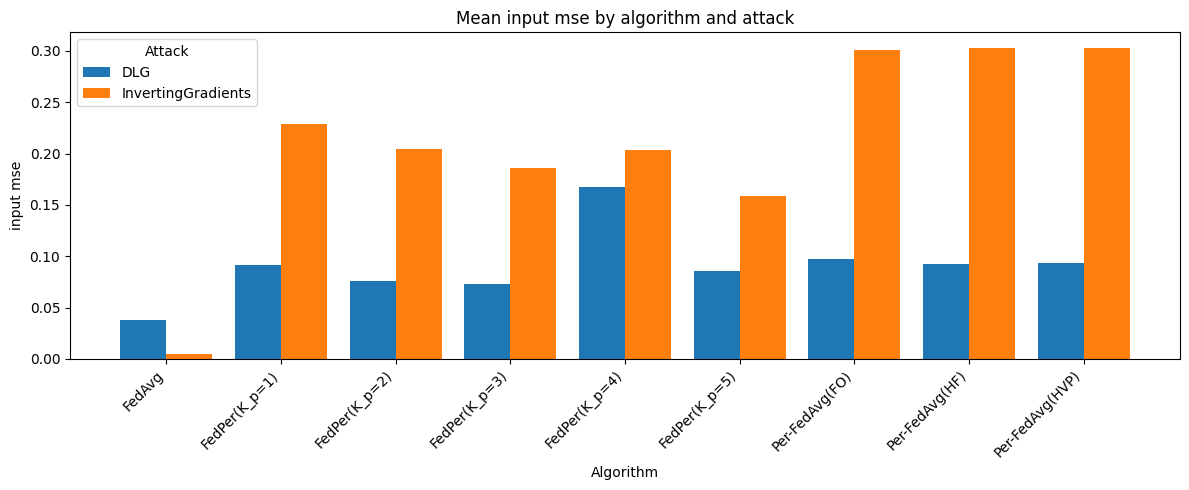

In [4]:
plot_attack_metric(attack_rows, "input mse")

<Axes: title={'center': 'Mean input psnr by algorithm and attack'}, xlabel='Algorithm', ylabel='input psnr'>

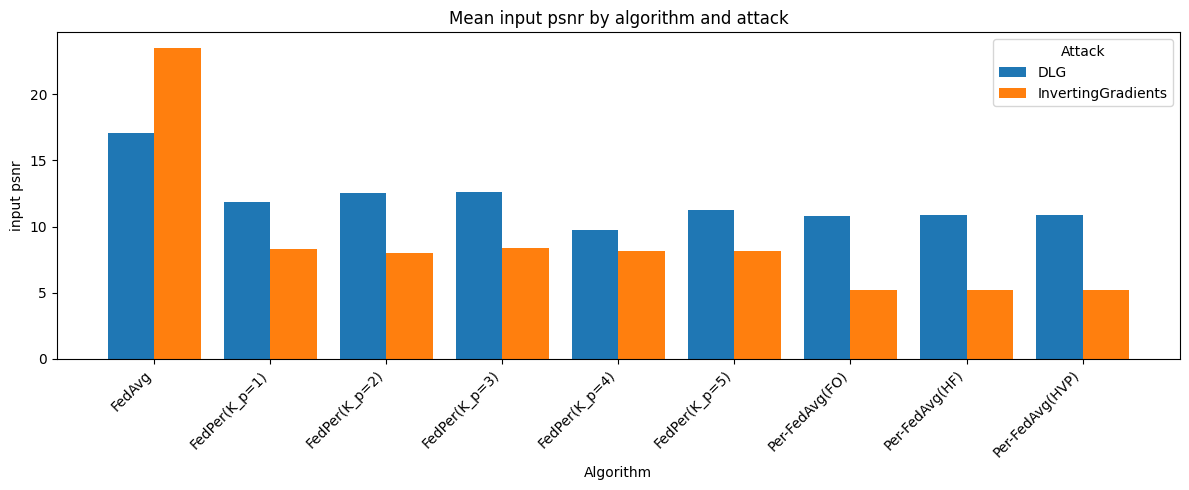

In [5]:
plot_attack_metric(attack_rows, "input psnr")

<Axes: title={'center': 'Mean input ssim by algorithm and attack'}, xlabel='Algorithm', ylabel='input ssim'>

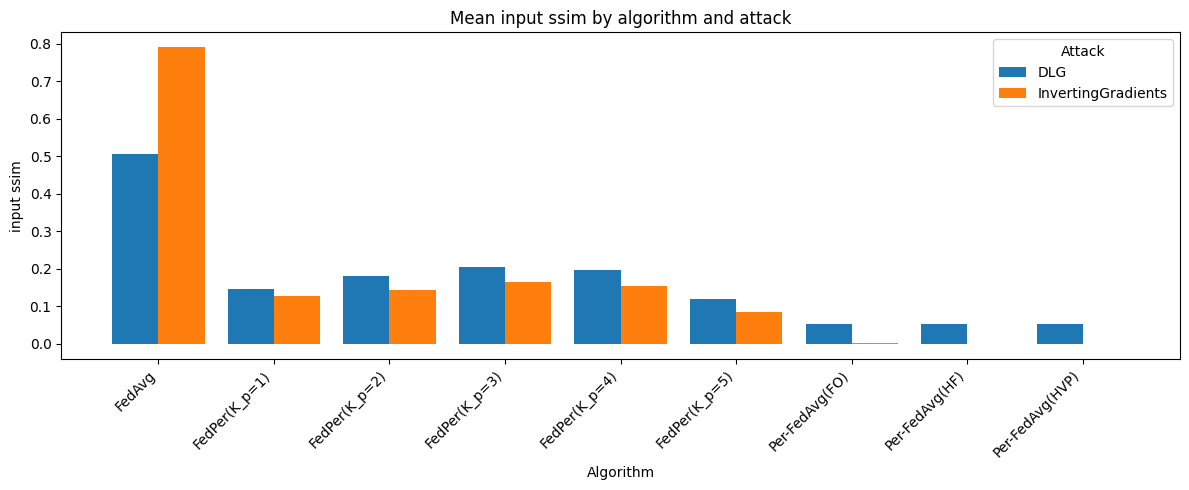

In [6]:
plot_attack_metric(attack_rows, "input ssim")

<Axes: title={'center': 'Label recovery by algorithm and attack'}, xlabel='Algorithm', ylabel='label_recover'>

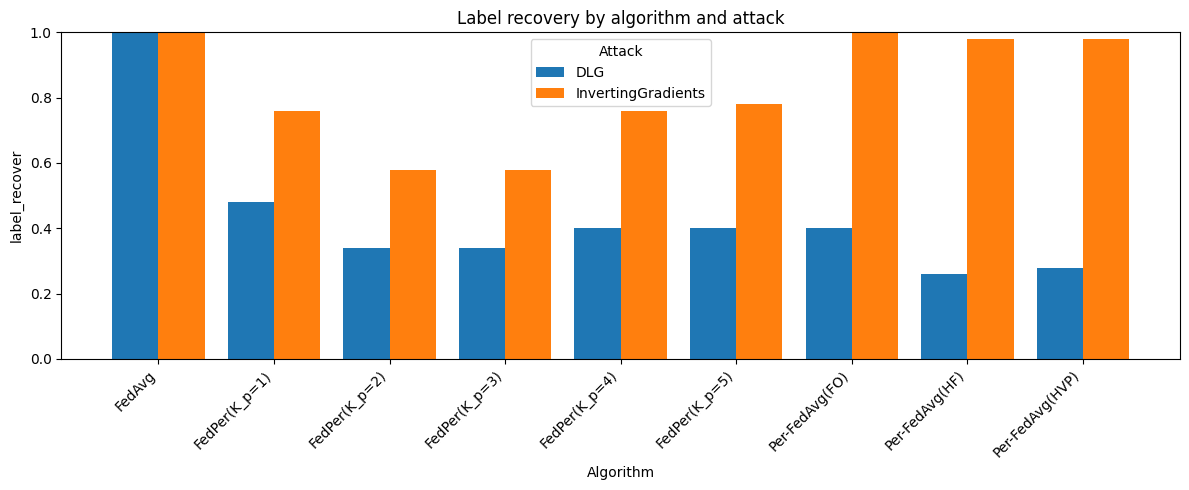

In [7]:
plot_attack_metric(attack_rows, "label_recover", title="Label recovery by algorithm and attack")

## Model Performance

<Axes: title={'center': 'Mean output crossentropy by algorithm'}, xlabel='Algorithm', ylabel='Output crossentropy'>

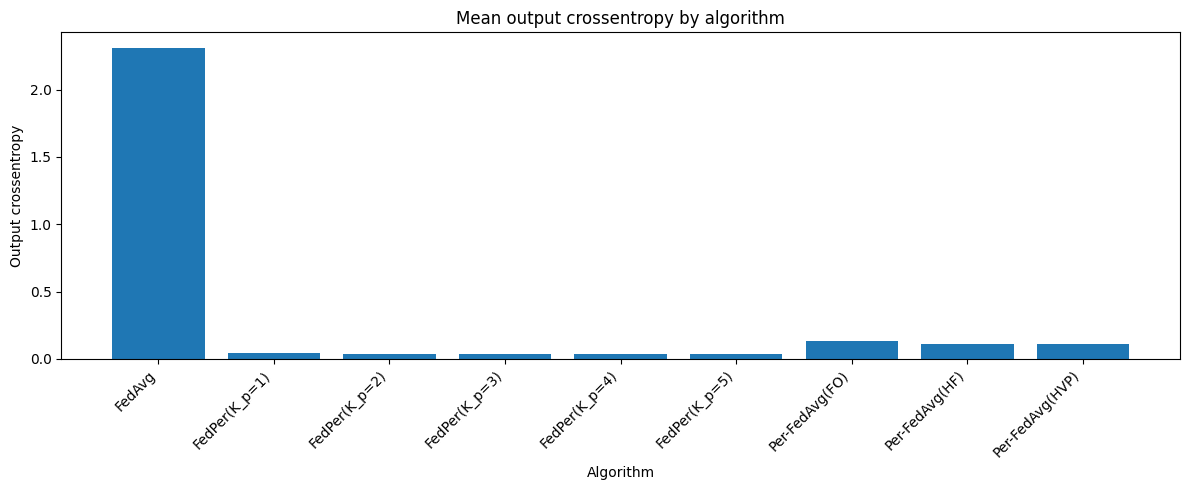

In [8]:
plot_algorithm_crossentropy(algorithm_rows)

<Axes: title={'center': 'Prediction accuracy by algorithm'}, xlabel='Algorithm', ylabel='Accuracy'>

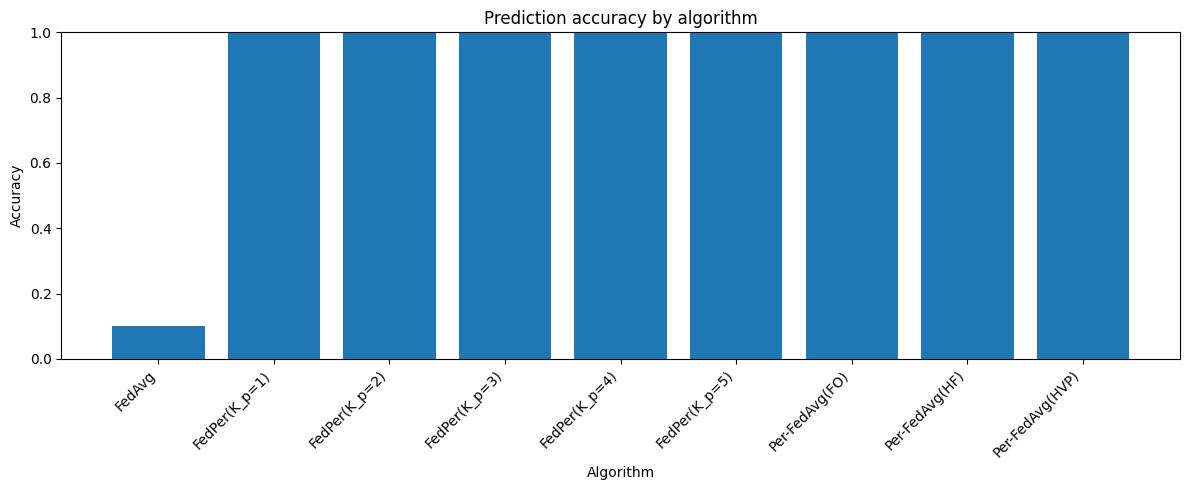

In [9]:
plot_algorithm_accuracy(algorithm_rows)